# Amino-acid ratios along the mammalian mitochondrial Major Arc

This notebook compares two amino-acid count ratios across the ten protein-coding
Major Arc genes encoded on the heavy strand:

1. $(\mathrm{Asn}+\mathrm{Lys})/\mathrm{Gly}$
2. $\mathrm{Pro}/(\mathrm{Phe}+\mathrm{Leu}_{\mathrm{TTA/TTG}})$

The genes follow their genomic order: **COX1, COX2, ATP8, ATP6, COX3, ND3,
ND4L, ND4, ND5, CytB**. ND1 and ND2 are outside this Major Arc definition;
ND6 is excluded because it is encoded on the opposite strand. The former
`Pro/Phe` ratio is not calculated because the second ratio retains the targeted
TTA/TTG-leucine information.

Every species has a QC-passing MIDORI2 CDS/protein pair for all ten genes. There
is no MutSpec intersection and no MutSpec weighting.


In [1]:
from collections import Counter
from itertools import combinations
from pathlib import Path
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch, Rectangle
from matplotlib.ticker import FuncFormatter, LogLocator
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import friedmanchisquare, page_trend_test, wilcoxon

here = Path.cwd().resolve()
ROOT = next(
    (path for path in (here, *here.parents)
     if (path / '6amino_acid_shift' / 'data' / 'midori').is_dir()),
    None,
)
if ROOT is None:
    raise FileNotFoundError('Run from the repository root or 6amino_acid_shift directory')

STAGE = ROOT / '6amino_acid_shift'
FIGURES = STAGE / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(STAGE))

from amino_acid_shift import TARGET_GENES
from midori_analysis import MIDORI_RELEASE, run_midori_analysis

GENE_ORDER = list(TARGET_GENES)
GENE_DISPLAY = {
    'CO1': 'COX1', 'CO2': 'COX2', 'A8': 'ATP8', 'A6': 'ATP6',
    'CO3': 'COX3', 'ND3': 'ND3', 'ND4L': 'ND4L', 'ND4': 'ND4',
    'ND5': 'ND5', 'Cytb': 'CytB',
}
GENE_LABELS = [GENE_DISPLAY[gene] for gene in GENE_ORDER]
GENE_COLORS = {
    'CO1': '#0072B2', 'CO2': '#348ABD', 'CO3': '#56B4E9',
    'A8': '#E69F00', 'A6': '#F0B44D',
    'ND3': '#8E6CBE', 'ND4L': '#9B7EBD', 'ND4': '#7A5195', 'ND5': '#5F4B8B',
    'Cytb': '#009E73',
}
RATIO_ORDER = ['(Asn+Lys)/Gly', 'Pro/(Phe+Leu[TTA/TTG])']
RATIO_LABELS = {
    '(Asn+Lys)/Gly': '(Asn + Lys) / Gly',
    'Pro/(Phe+Leu[TTA/TTG])': 'Pro / (Phe + Leu[TTA/TTG])',
}
PSEUDOCOUNT = 0.5
TEXT = '#20262E'

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9.5,
    'axes.labelcolor': TEXT,
    'axes.titlecolor': TEXT,
    'xtick.color': TEXT,
    'ytick.color': TEXT,
    'text.color': TEXT,
    'axes.linewidth': 0.8,
    'pdf.fonttype': 42,
    'savefig.facecolor': 'white',
})

print(f'MIDORI2 release: {MIDORI_RELEASE}')
print('Major Arc genes:', ', '.join(GENE_LABELS))


MIDORI2 release: GenBank272_2026-06-07
Major Arc genes: COX1, COX2, ATP8, ATP6, COX3, ND3, ND4L, ND4, ND5, CytB


## 1. MIDORI2 extraction and sequence QC

The acquisition backend scans mammalian `UNIQ_NUC` and `TOTAL_AA` archives for
all ten genes. A protein is paired with a CDS only when accession and coordinates
match. Candidate selection is deterministic and happens before any ratio is
calculated. The CDS must reproduce the paired protein under vertebrate
mitochondrial translation table 2.

Restricting the sequence cohort to species represented by every target gene
makes all gene comparisons paired and prevents changes in species composition
from masquerading as gene effects. The cache is rebuilt automatically if its
gene set does not match the current target list.


In [2]:
SEQUENCES_PATH = STAGE / 'data' / 'derived_midori' / 'midori_gene_sequences.csv.gz'

def cache_matches_targets(data):
    if set(data.get('Gene', ())) != set(TARGET_GENES):
        return False
    per_species = data.groupby('Species')['Gene'].nunique()
    return bool(len(per_species) and per_species.eq(len(TARGET_GENES)).all())

analysis_qc = None
if SEQUENCES_PATH.is_file():
    cached = pd.read_csv(SEQUENCES_PATH, dtype={'TaxID': str})
    if cache_matches_targets(cached):
        analysis_qc = cached
        source_message = f'Loaded existing QC table: {SEQUENCES_PATH.name}'

if analysis_qc is None:
    results = run_midori_analysis(STAGE, class_filter='Mammalia')
    analysis_qc = results['analysis_qc'].copy()
    source_message = 'Rebuilt the QC table from cached MIDORI2 archives'

n_species = analysis_qc['Species'].nunique()
assert set(analysis_qc['Gene']) == set(TARGET_GENES)
assert len(analysis_qc) == n_species * len(TARGET_GENES)
assert analysis_qc.groupby('Species')['Gene'].nunique().eq(len(TARGET_GENES)).all()
assert analysis_qc['sequence_qc_status'].eq('pass').all()
assert analysis_qc['translation_match'].all()
assert analysis_qc['same_feature_pair'].all()

print(source_message)
print(f'Paired QC cohort: {n_species:,} mammalian species; {len(analysis_qc):,} gene records.')


Loaded existing QC table: midori_gene_sequences.csv.gz
Paired QC cohort: 1,932 mammalian species; 19,320 gene records.


## 2. Count amino acids and calculate the two ratios

P, F, N, K, and G are counted in each validated protein. `Leu[TTA/TTG]` is
counted from its matched CDS because an amino-acid sequence cannot identify the
synonymous leucine codon. Other leucine codons are deliberately excluded.

ATP8 is short and often contains no glycine; a few ND4L proteins contain no
proline. Raw ratios would therefore be infinite or zero. We preserve the raw
counts and raw ratio where defined, but use the explicit Jeffreys/Haldane
continuity correction

$$R^*=(\mathrm{numerator}+0.5)/(\mathrm{denominator}+0.5)$$

for statistical tests, fold changes, and figures. This avoids silently dropping
the biologically informative zero counts. No gene-length normalization is
needed because the same length factor would cancel within each ratio.


In [3]:
count_rows = []
for row in analysis_qc.itertuples(index=False):
    protein = str(row.computed_translation).rstrip('*')
    coding = str(row.coding_cds_sequence)
    codons = [coding[i:i + 3] for i in range(0, len(coding) - 2, 3)]
    amino_acids = Counter(protein)
    count_rows.append({
        'Species': row.Species,
        'TaxID': str(row.TaxID),
        'Gene': row.Gene,
        'aa_length': len(protein),
        'P': amino_acids['P'],
        'F': amino_acids['F'],
        'N': amino_acids['N'],
        'K': amino_acids['K'],
        'G': amino_acids['G'],
        'Leu_TTA_TTG': sum(codon in {'TTA', 'TTG'} for codon in codons),
    })

counts = pd.DataFrame(count_rows)
counts['Asn_plus_Lys'] = counts['N'] + counts['K']
counts['Phe_plus_Leu_TTR'] = counts['F'] + counts['Leu_TTA_TTG']

ratio_components = {
    '(Asn+Lys)/Gly': ('Asn_plus_Lys', 'G'),
    'Pro/(Phe+Leu[TTA/TTG])': ('P', 'Phe_plus_Leu_TTR'),
}
zero_rows = []
for ratio_name, (numerator_col, denominator_col) in ratio_components.items():
    numerator = counts[numerator_col].to_numpy(dtype=float)
    denominator = counts[denominator_col].to_numpy(dtype=float)
    counts[f'{ratio_name} raw'] = np.divide(
        numerator, denominator,
        out=np.full(len(counts), np.nan), where=denominator > 0,
    )
    counts[ratio_name] = (numerator + PSEUDOCOUNT) / (denominator + PSEUDOCOUNT)
    counts[f'log2 {ratio_name}'] = np.log2(counts[ratio_name])
    for gene in GENE_ORDER:
        gene_rows = counts['Gene'].eq(gene)
        zero_rows.append({
            'Ratio': ratio_name,
            'Gene': GENE_DISPLAY[gene],
            'zero numerator': int((counts.loc[gene_rows, numerator_col] == 0).sum()),
            'zero denominator': int((counts.loc[gene_rows, denominator_col] == 0).sum()),
        })

zero_counts = pd.DataFrame(zero_rows)
assert np.isfinite(counts[RATIO_ORDER].to_numpy()).all()
ratio_data = counts.melt(
    id_vars=['Species', 'TaxID', 'Gene'],
    value_vars=RATIO_ORDER,
    var_name='Ratio', value_name='Value',
)

display(zero_counts.loc[
    zero_counts[['zero numerator', 'zero denominator']].gt(0).any(axis=1)
].reset_index(drop=True))
print(f'Calculated {len(ratio_data):,} corrected species × gene × ratio observations in memory.')


Calculated 38,640 corrected species × gene × ratio observations in memory.


,Ratio,Gene,zero numerator,zero denominator
0,(Asn+Lys)/Gly,ATP8,0,1819
1,Pro/(Phe+Leu[TTA/TTG]),ND4L,7,0


## 3. Repeated-measures comparison and directed post-hoc tests

Each species contributes ten linked measurements. A Friedman test asks whether
at least one gene differs, and Kendall's $W$ gives its omnibus effect size. A
one-sided Page trend test evaluates the pre-specified increase along the genomic
Major Arc order. ATP8/ATP6 and ND4L/ND4 overlap in the genome, so the ordered
test is interpreted as a broad positional trend rather than ten independent
physical steps.

All 45 forward gene pairs are then tested as `later gene > earlier gene` using
one-sided paired Wilcoxon signed-rank tests on log2 corrected ratios. Holm
correction is applied across the 45 post-hoc tests within each ratio. The nine
adjacent comparisons and the COX1-to-CytB endpoint are marked as planned; all
other pairs remain available in `pairwise_results` and appear as effects in
Figure 2. No comparison is selected because its observed effect happens to be
large.


In [4]:
def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    ordered = p_values[order]
    adjusted_ordered = np.maximum.accumulate(
        (len(ordered) - np.arange(len(ordered))) * ordered
    )
    adjusted = np.empty_like(adjusted_ordered)
    adjusted[order] = np.minimum(adjusted_ordered, 1.0)
    return adjusted

def table_p_value(p_value):
    if p_value == 0 or p_value < 1e-300:
        return '< 1e-300'
    return f'{p_value:.3e}'

omnibus_rows = []
pairwise_rows = []
for ratio_name in RATIO_ORDER:
    log_column = f'log2 {ratio_name}'
    wide = (
        counts.pivot(index='Species', columns='Gene', values=log_column)
        .loc[:, GENE_ORDER]
        .dropna()
    )
    friedman = friedmanchisquare(*(wide[gene] for gene in GENE_ORDER))
    page = page_trend_test(wide.to_numpy(), ranked=False, method='auto')
    omnibus_rows.append({
        'Ratio': ratio_name,
        'n paired species': len(wide),
        'Friedman Q': float(friedman.statistic),
        'Friedman df': len(GENE_ORDER) - 1,
        'Friedman p-value': float(friedman.pvalue),
        "Kendall's W": float(friedman.statistic) / (
            len(wide) * (len(GENE_ORDER) - 1)
        ),
        'Page L': float(page.statistic),
        'Page p-value (increasing)': float(page.pvalue),
    })

    ratio_rows = []
    for first_index, second_index in combinations(range(len(GENE_ORDER)), 2):
        first_gene = GENE_ORDER[first_index]
        second_gene = GENE_ORDER[second_index]
        difference = wide[second_gene] - wide[first_gene]
        paired_test = wilcoxon(
            wide[second_gene], wide[first_gene], alternative='greater',
            zero_method='wilcox', method='approx',
        )
        fold_change = np.exp2(difference)
        adjacent = second_index == first_index + 1
        endpoint = first_index == 0 and second_index == len(GENE_ORDER) - 1
        ratio_rows.append({
            'Ratio': ratio_name,
            'Earlier gene': GENE_DISPLAY[first_gene],
            'Later gene': GENE_DISPLAY[second_gene],
            'Contrast': f'{GENE_DISPLAY[second_gene]} / {GENE_DISPLAY[first_gene]}',
            'Alternative': f'{GENE_DISPLAY[second_gene]} > {GENE_DISPLAY[first_gene]}',
            'n pairs': len(wide),
            'n non-zero': int(np.count_nonzero(difference.to_numpy())),
            'Wilcoxon W': float(paired_test.statistic),
            'p-value raw': float(paired_test.pvalue),
            'Median log2 difference': float(difference.median()),
            'Median fold change': float(fold_change.median()),
            'Species with increase (%)': float(100 * difference.gt(0).mean()),
            'Adjacent': adjacent,
            'Endpoint': endpoint,
            'Planned': adjacent or endpoint,
            'earlier_index': first_index,
            'later_index': second_index,
        })
    adjusted = holm_adjust([row['p-value raw'] for row in ratio_rows])
    for row, adjusted_p in zip(ratio_rows, adjusted):
        row['p-value Holm (45 pairs)'] = float(adjusted_p)
    pairwise_rows.extend(ratio_rows)

omnibus_results = pd.DataFrame(omnibus_rows)
omnibus_results['Friedman p-value Holm'] = holm_adjust(omnibus_results['Friedman p-value'])
omnibus_results['Page p-value Holm'] = holm_adjust(omnibus_results['Page p-value (increasing)'])
pairwise_results = pd.DataFrame(pairwise_rows)

omnibus_display = omnibus_results.copy()
for column in ['Friedman p-value', 'Page p-value (increasing)',
               'Friedman p-value Holm', 'Page p-value Holm']:
    omnibus_display[column] = omnibus_display[column].map(table_p_value)
for column in ['Friedman Q', "Kendall's W", 'Page L']:
    omnibus_display[column] = omnibus_display[column].map(lambda value: f'{value:.3f}')
display(omnibus_display)

planned_display = pairwise_results.loc[pairwise_results['Planned'], [
    'Ratio', 'Contrast', 'Alternative', 'n pairs', 'n non-zero',
    'p-value raw', 'p-value Holm (45 pairs)', 'Median fold change',
    'Species with increase (%)', 'Adjacent', 'Endpoint',
]].copy()
for column in ['p-value raw', 'p-value Holm (45 pairs)']:
    planned_display[column] = planned_display[column].map(table_p_value)
planned_display['Median fold change'] = planned_display['Median fold change'].map(
    lambda value: f'{value:.3f}'
)
planned_display['Species with increase (%)'] = planned_display[
    'Species with increase (%)'
].map(lambda value: f'{value:.1f}')
display(planned_display.reset_index(drop=True))
print(f'All post-hoc results remain in pairwise_results: {len(pairwise_results)} rows.')


All post-hoc results remain in pairwise_results: 90 rows.


,Ratio,n paired species,Friedman Q,Friedman df,Friedman p-value,Kendall's W,Page L,Page p-value (increasing),Friedman p-value Holm,Page p-value Holm
0,(Asn+Lys)/Gly,1932,16118.213,9,< 1e-300,0.927,608383.500,1.067e-87,< 1e-300,2.134e-87
1,Pro/(Phe+Leu[TTA/TTG]),1932,14428.779,9,< 1e-300,0.830,538124.000,1.000e+00,< 1e-300,1.000e+00


,Ratio,Contrast,Alternative,n pairs,n non-zero,p-value raw,p-value Holm (45 pairs),Median fold change,Species with increase (%),Adjacent,Endpoint
0,(Asn+Lys)/Gly,COX2 / COX1,COX2 > COX1,1932,1932,< 1e-300,< 1e-300,2.301,100.0,True,False
1,(Asn+Lys)/Gly,CytB / COX1,CytB > COX1,1932,1932,< 1e-300,< 1e-300,1.863,100.0,False,True
2,(Asn+Lys)/Gly,ATP8 / COX2,ATP8 > COX2,1932,1932,< 1e-300,< 1e-300,12.391,100.0,True,False
3,(Asn+Lys)/Gly,ATP6 / ATP8,ATP6 > ATP8,1932,1932,1.000e+00,1.000e+00,0.084,0.1,True,False
4,(Asn+Lys)/Gly,COX3 / ATP6,COX3 > ATP6,1932,1932,1.000e+00,1.000e+00,0.362,0.0,True,False
5,(Asn+Lys)/Gly,ND3 / COX3,ND3 > COX3,1932,1932,< 1e-300,< 1e-300,4.669,100.0,True,False
6,(Asn+Lys)/Gly,ND4L / ND3,ND4L > ND3,1932,1914,1.000e+00,1.000e+00,0.570,2.6,True,False
7,(Asn+Lys)/Gly,ND4 / ND4L,ND4 > ND4L,1932,1931,< 1e-300,< 1e-300,1.482,99.0,True,False
8,(Asn+Lys)/Gly,ND5 / ND4,ND5 > ND4,1932,1931,2.840e-134,6.532e-133,1.078,75.4,True,False
9,(Asn+Lys)/Gly,CytB / ND5,CytB > ND5,1932,1932,1.000e+00,1.000e+00,0.519,0.0,True,False


## 4. Ratio distributions along the Major Arc

The two panels use the same ten-gene paired cohort. Violin width shows the
species distribution, the narrow box shows its central range, colored dots are
medians, and faint lines retain the within-species trajectories. The logarithmic
y-axis is appropriate for positive ratios and keeps short ATP8 visible without
compressing the other genes.

As requested, each boxplot panel contains only the pre-specified endpoint
annotation: the one-sided paired Wilcoxon p-value for `CytB > COX1`. The full
ten-gene tests and post-hoc results remain in the tables above.


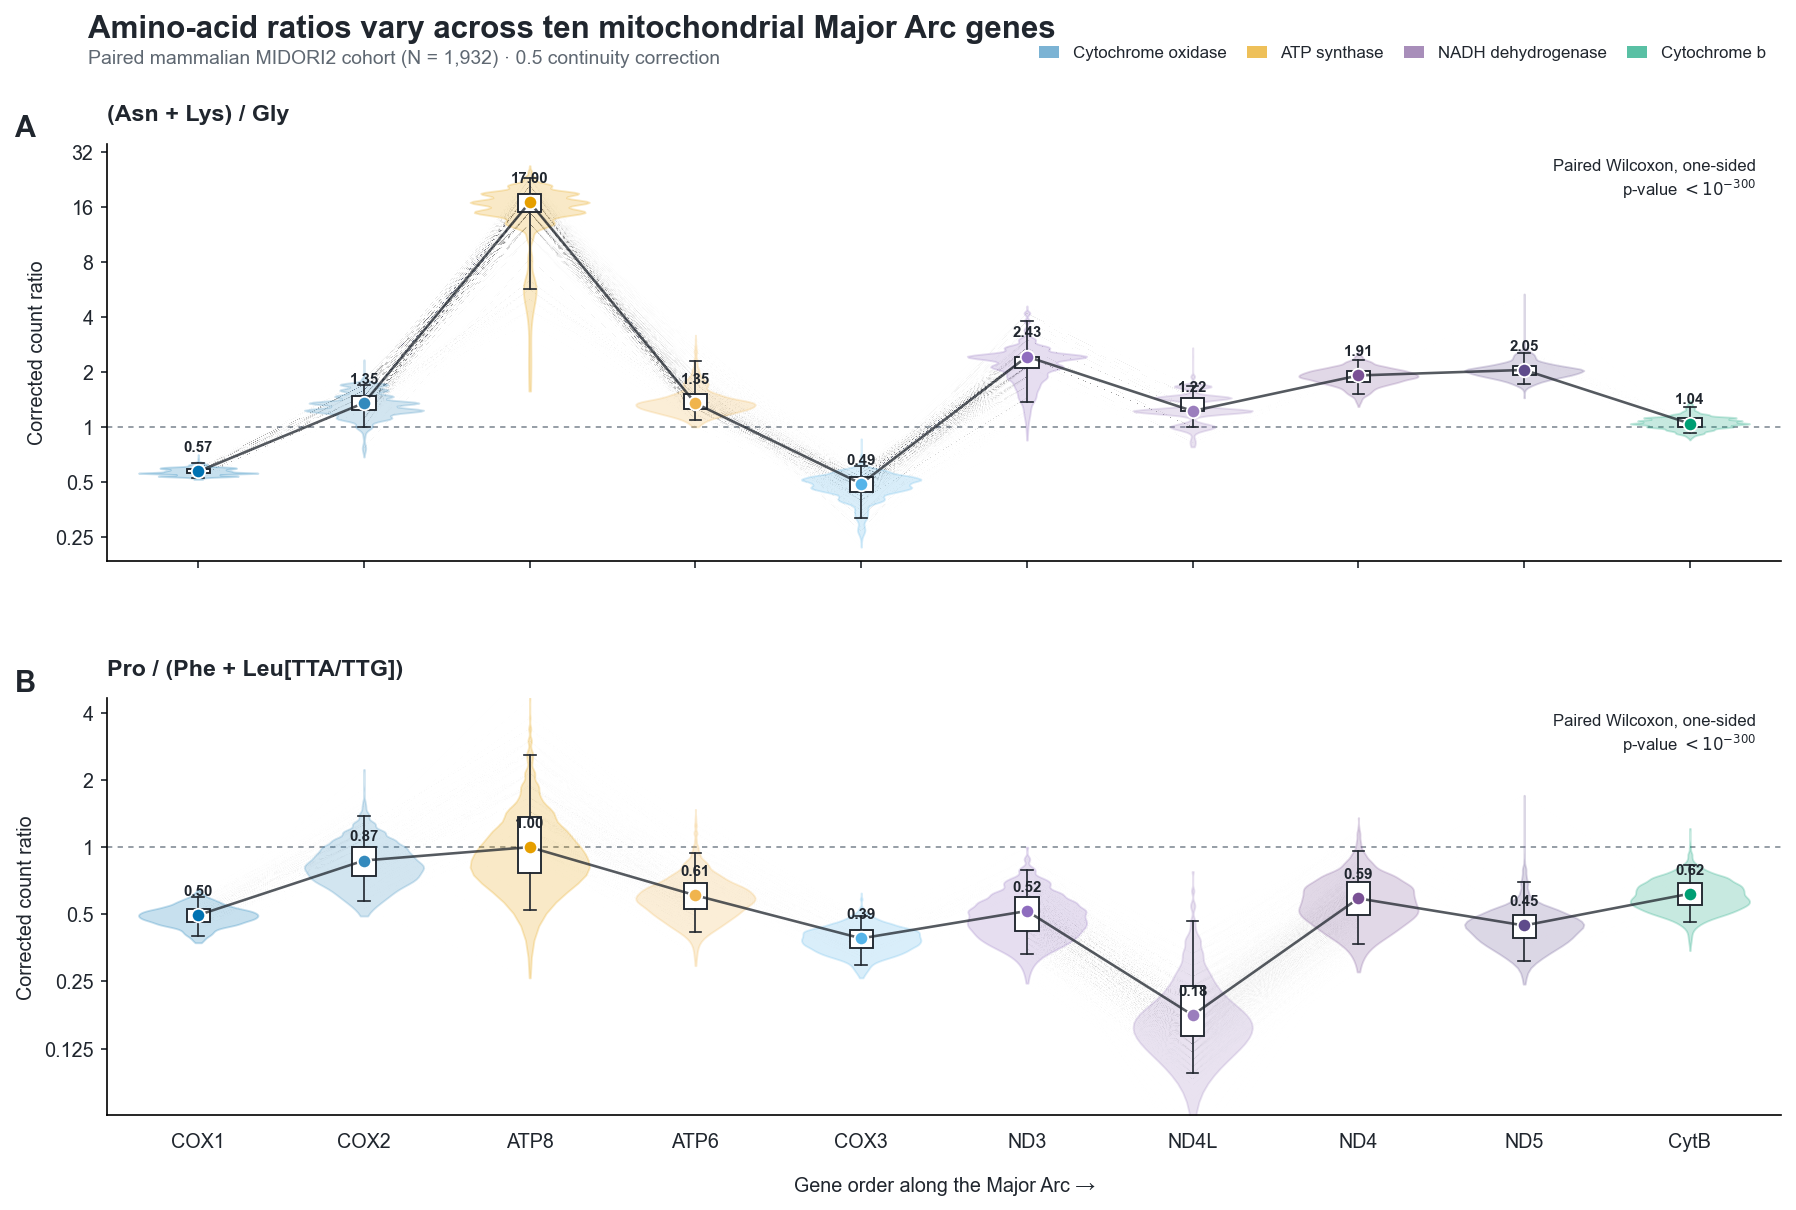

In [5]:
def format_p_value(p_value):
    if p_value == 0 or p_value < 1e-300:
        return r'$< 10^{-300}$'
    if p_value < 0.001:
        exponent = int(np.floor(np.log10(p_value)))
        coefficient = p_value / (10 ** exponent)
        return rf'$= {coefficient:.2f} \times 10^{{{exponent}}}$'
    return rf'$= {p_value:.3f}$'

positions = np.arange(len(GENE_ORDER))
fig, axes = plt.subplots(2, 1, figsize=(12.4, 8.2), sharex=True)

for panel_index, (axis, ratio_name) in enumerate(zip(axes, RATIO_ORDER)):
    paired_values = (
        counts.pivot(index='Species', columns='Gene', values=ratio_name)
        .loc[:, GENE_ORDER]
    )
    distributions = [paired_values[gene].to_numpy() for gene in GENE_ORDER]

    for species_values in paired_values.to_numpy():
        axis.plot(
            positions, species_values, color='#667085', alpha=0.0022,
            linewidth=0.22, zorder=0.4, rasterized=True,
        )

    endpoint_test = pairwise_results.loc[
        pairwise_results['Ratio'].eq(ratio_name)
        & pairwise_results['Endpoint']
    ].iloc[0]
    endpoint_p = float(endpoint_test['p-value raw'])

    violins = axis.violinplot(
        distributions, positions=positions, widths=0.72,
        showmeans=False, showmedians=False, showextrema=False,
        bw_method=0.18,
    )
    for body, gene in zip(violins['bodies'], GENE_ORDER):
        body.set_facecolor(GENE_COLORS[gene])
        body.set_edgecolor(GENE_COLORS[gene])
        body.set_alpha(0.22)
        body.set_linewidth(0.9)

    axis.boxplot(
        distributions, positions=positions, widths=0.14,
        whis=(2.5, 97.5), showfliers=False, patch_artist=True,
        boxprops={'facecolor': 'white', 'edgecolor': TEXT, 'linewidth': 0.9},
        whiskerprops={'color': TEXT, 'linewidth': 0.8},
        capprops={'color': TEXT, 'linewidth': 0.8},
        medianprops={'color': 'white', 'linewidth': 0},
    )
    medians = np.array([np.median(values) for values in distributions])
    axis.plot(positions, medians, color=TEXT, linewidth=1.25, alpha=0.76, zorder=4)
    for x, median, gene in zip(positions, medians, GENE_ORDER):
        axis.scatter(
            x, median, s=42, color=GENE_COLORS[gene],
            edgecolor='white', linewidth=0.9, zorder=5,
        )
        axis.annotate(
            f'{median:.2f}', (x, median), xytext=(0, 8),
            textcoords='offset points', ha='center', va='bottom',
            fontsize=7.2, fontweight='bold', color=TEXT,
        )

    all_values = paired_values.to_numpy().ravel()
    lower, upper = np.quantile(all_values, [0.001, 0.999])
    axis.set_yscale('log', base=2)
    axis.set_ylim(lower / 1.45, upper * 1.55)
    axis.yaxis.set_major_locator(LogLocator(base=2, numticks=9))
    axis.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:g}'))
    axis.axhline(1, color='#8C949D', linewidth=0.85,
                 linestyle=(0, (3, 3)), zorder=0)
    axis.text(
        0.985, 0.965,
        'Paired Wilcoxon, one-sided\n'
        + 'p-value ' + format_p_value(endpoint_p),
        transform=axis.transAxes, ha='right', va='top', fontsize=8.0,
        linespacing=1.25, color=TEXT,
        bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.88, 'pad': 2.2},
        zorder=8,
    )
    axis.set_title(RATIO_LABELS[ratio_name], loc='left', fontsize=11.2,
                   fontweight='bold', pad=11)
    axis.text(-0.055, 1.07, chr(65 + panel_index), transform=axis.transAxes,
              fontsize=14, fontweight='bold', va='top')
    axis.set_ylabel('Corrected count ratio')
    axis.spines[['top', 'right']].set_visible(False)
    axis.tick_params(axis='y', length=3)

axes[-1].set_xticks(positions, GENE_LABELS)
axes[-1].tick_params(axis='x', length=0, pad=8)
axes[-1].set_xlabel('Gene order along the Major Arc →', labelpad=12)
for axis in axes:
    axis.set_xlim(-0.55, len(GENE_ORDER) - 0.45)

legend_handles = [
    Patch(facecolor='#348ABD', alpha=0.65, label='Cytochrome oxidase'),
    Patch(facecolor='#E69F00', alpha=0.65, label='ATP synthase'),
    Patch(facecolor='#7A5195', alpha=0.65, label='NADH dehydrogenase'),
    Patch(facecolor='#009E73', alpha=0.65, label='Cytochrome b'),
]
fig.suptitle('Amino-acid ratios vary across ten mitochondrial Major Arc genes',
             x=0.075, y=0.995, ha='left', fontsize=15, fontweight='bold')
fig.text(0.075, 0.955,
         f'Paired mammalian MIDORI2 cohort (N = {n_species:,}) · 0.5 continuity correction',
         fontsize=9.3, color='#5F6872')
fig.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(0.985, 0.982),
           ncol=4, frameon=False, fontsize=8.1, handlelength=1.2,
           columnspacing=1.2)
fig.subplots_adjust(left=0.085, right=0.985, bottom=0.10, top=0.89, hspace=0.33)

figure_one = FIGURES / 'amino_acid_ratios_by_gene'
fig.savefig(figure_one.with_suffix('.png'), dpi=400, bbox_inches='tight')
fig.savefig(figure_one.with_suffix('.pdf'), bbox_inches='tight')
plt.show()
plt.close(fig)


![Two amino-acid ratios across ten Major Arc genes](figures/amino_acid_ratios_by_gene.png)

**Figure 1. Amino-acid ratios by gene.** Each faint trajectory follows one
mammalian species across all ten genes. Distributions and statistics use the
explicit 0.5 continuity correction. The annotation in each panel is only the
pre-specified `CytB > COX1` one-sided paired Wilcoxon test; it is not a test of
the entire trajectory.


## 5. All pairwise within-species fold changes

Ten genes generate 45 unique forward pairs per ratio. Selecting only the largest
effects after seeing the data would be misleading, while a 90-row forest plot
would be difficult to read. Figure 2 therefore retains **every pair** in two
upper-triangular matrices.

Each cell is the median within-species fold change `later / earlier`. Blue means
a decrease, red means an increase, and white is no change. Thin outlines mark
the nine pre-specified adjacent comparisons; the thicker gold outline marks the
COX1-to-CytB endpoint. P-values remain in `pairwise_results`, not in this effect
figure.


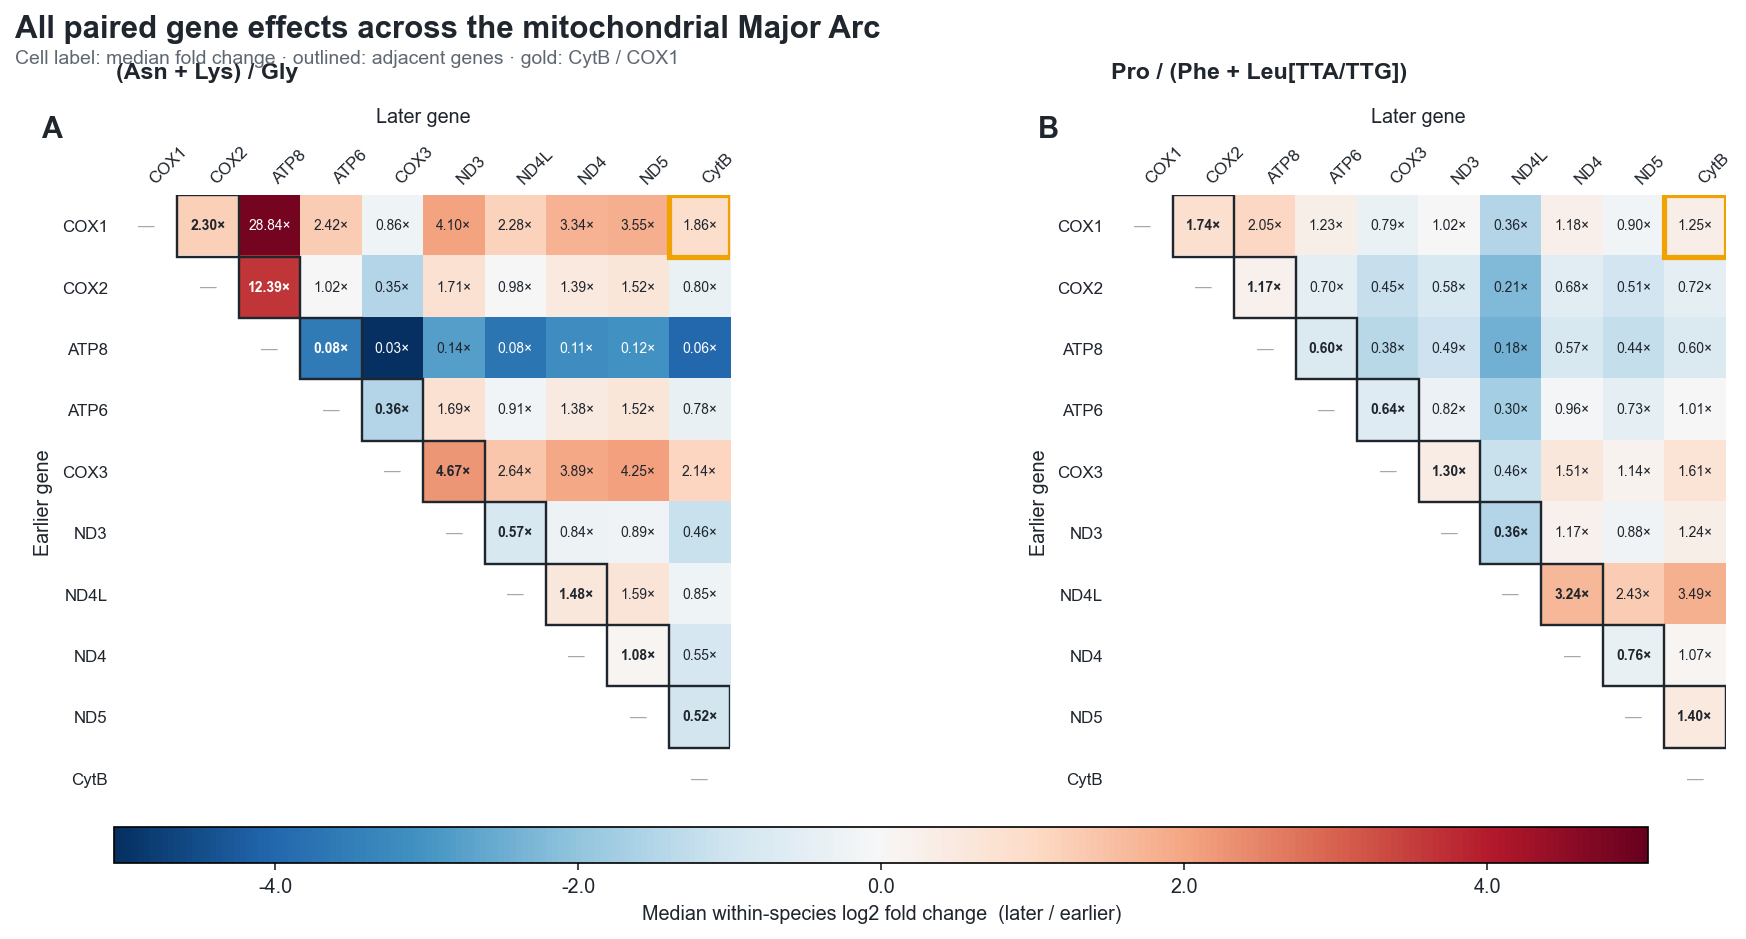

In [6]:
effect_matrix_data = pairwise_results[[
    'Ratio', 'earlier_index', 'later_index', 'Median fold change',
]].copy()
effect_matrix_data['Median log2 fold change'] = np.log2(
    effect_matrix_data['Median fold change']
)
max_abs = float(effect_matrix_data['Median log2 fold change'].abs().max())
norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
cmap = mpl.colormaps['RdBu_r'].copy()
cmap.set_bad('white')

fig, axes = plt.subplots(1, 2, figsize=(13.2, 6.5), constrained_layout=False)
last_image = None
for panel_index, (axis, ratio_name) in enumerate(zip(axes, RATIO_ORDER)):
    matrix = np.full((len(GENE_ORDER), len(GENE_ORDER)), np.nan)
    fold_matrix = np.full_like(matrix, np.nan)
    subset = effect_matrix_data.loc[effect_matrix_data['Ratio'].eq(ratio_name)]
    for _, row in subset.iterrows():
        earlier_index = int(row['earlier_index'])
        later_index = int(row['later_index'])
        matrix[earlier_index, later_index] = row['Median log2 fold change']
        fold_matrix[earlier_index, later_index] = row['Median fold change']

    last_image = axis.imshow(matrix, cmap=cmap, norm=norm, aspect='equal')
    for earlier_index in range(len(GENE_ORDER)):
        for later_index in range(earlier_index + 1, len(GENE_ORDER)):
            value = matrix[earlier_index, later_index]
            fold = fold_matrix[earlier_index, later_index]
            color = 'white' if abs(value) > 0.58 * max_abs else TEXT
            axis.text(later_index, earlier_index, f'{fold:.2f}×',
                      ha='center', va='center', fontsize=6.7,
                      fontweight='bold' if later_index == earlier_index + 1 else 'normal',
                      color=color)
            if later_index == earlier_index + 1:
                axis.add_patch(Rectangle(
                    (later_index - 0.5, earlier_index - 0.5), 1, 1,
                    fill=False, edgecolor='#20262E', linewidth=1.15,
                ))
        axis.text(earlier_index, earlier_index, '—', ha='center', va='center',
                  fontsize=8, color='#A4A9AF')

    axis.add_patch(Rectangle(
        (len(GENE_ORDER) - 1.5, -0.5), 1, 1,
        fill=False, edgecolor='#F0A202', linewidth=2.5,
    ))
    axis.set_xticks(range(len(GENE_ORDER)), GENE_LABELS, rotation=45, ha='left')
    axis.set_yticks(range(len(GENE_ORDER)), GENE_LABELS)
    axis.xaxis.tick_top()
    axis.tick_params(axis='both', length=0, pad=4, labelsize=8.1)
    axis.set_xlabel('Later gene', labelpad=10)
    axis.xaxis.set_label_position('top')
    axis.set_ylabel('Earlier gene')
    axis.set_title(RATIO_LABELS[ratio_name], loc='left', fontsize=11.2,
                   fontweight='bold', pad=14)
    axis.text(-0.12, 1.13, chr(65 + panel_index), transform=axis.transAxes,
              fontsize=14, fontweight='bold', va='top')
    axis.spines[:].set_visible(False)

colorbar = fig.colorbar(last_image, ax=axes, orientation='horizontal',
                        fraction=0.055, pad=0.10, aspect=42)
colorbar.set_label('Median within-species log2 fold change  (later / earlier)')
colorbar.ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:.1f}'))
fig.suptitle('All paired gene effects across the mitochondrial Major Arc',
             x=0.075, y=0.985, ha='left', fontsize=15, fontweight='bold')
fig.text(0.075, 0.935,
         'Cell label: median fold change · outlined: adjacent genes · gold: CytB / COX1',
         fontsize=9.3, color='#5F6872')
fig.subplots_adjust(left=0.08, right=0.985, bottom=0.17, top=0.80, wspace=0.25)

figure_two = FIGURES / 'paired_ratio_fold_changes'
fig.savefig(figure_two.with_suffix('.png'), dpi=400, bbox_inches='tight')
fig.savefig(figure_two.with_suffix('.pdf'), bbox_inches='tight')
plt.show()
plt.close(fig)


![All paired fold changes among ten Major Arc genes](figures/paired_ratio_fold_changes.png)

**Figure 2. All pairwise gene effects.** Rows are earlier genes and columns are
later genes. Every one of the 45 forward comparisons is shown for each ratio.
The matrix reports effect size only; inferential results are kept in the
notebook tables so the figure does not become a p-value map.


## 6. Interpretation limits

The analysis describes the available MIDORI2 mammalian sample. Species are not
phylogenetically independent, and taxonomic sampling is uneven, so extremely
small p-values should not be read as phylogenetically corrected evidence. The
paired effects, their direction across species, and the full gene profile are
more informative here. ATP8/ATP6 and ND4L/ND4 overlap in physical coordinates;
the Major Arc order is a positional proxy, not ten equally spaced independent
exposure levels.
